In [11]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from torch import optim
import time
import random
from sklearn.model_selection import train_test_split
from mplsoccer import Pitch
from sklearn.metrics import roc_auc_score

In [3]:
data = pd.read_csv("flatten_data.csv")
data.head()

,frame,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,create,direct,disruption,finish,quick_break,set_play,transition,direction,lead_to_goal,match_id
0,28.0,0.11,0.32,0.29,0.49,0.31,0.44,0.41,0.50,0.49,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1886347
1,48.0,0.12,0.30,0.29,0.54,0.30,0.46,0.40,0.55,0.54,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1886347
2,49.0,0.12,0.29,0.29,0.54,0.30,0.46,0.40,0.56,0.55,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1886347
3,50.0,0.12,0.29,0.29,0.55,0.30,0.46,0.40,0.56,0.55,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1886347
4,51.0,0.12,0.29,0.29,0.55,0.30,0.46,0.40,0.56,0.56,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1886347


In [3]:
data.describe()

,frame,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,create,direct,disruption,finish,quick_break,set_play,transition,direction,lead_to_goal,match_id
count,207268.000000,207268.000000,207268.000000,207268.000000,207268.000000,207268.000000,207268.000000,207268.000000,207268.000000,207268.000000,...,207268.000000,207268.000000,207268.000000,207268.000000,207268.000000,207268.000000,207268.000000,207268.000000,207268.000000,2.072680e+05
mean,30552.832208,0.134013,0.344393,0.351709,0.413596,0.428667,0.445072,0.459798,0.527198,0.558067,...,0.380802,0.040233,0.006103,0.254154,0.018102,0.022150,0.038197,0.473947,0.008578,1.970869e+06
std,19281.857122,0.076630,0.159004,0.162062,0.191870,0.195291,0.186587,0.180825,0.191495,0.187880,...,0.485585,0.196506,0.077884,0.435386,0.133321,0.147172,0.191672,0.499322,0.092221,4.912615e+04
min,12.000000,-0.040000,-0.020000,-0.020000,-0.020000,-0.030000,0.010000,0.020000,0.010000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.886347e+06
25%,13178.000000,0.070000,0.220000,0.230000,0.270000,0.280000,0.300000,0.330000,0.390000,0.430000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.925299e+06
50%,27695.000000,0.130000,0.350000,0.350000,0.400000,0.420000,0.440000,0.460000,0.530000,0.560000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.996435e+06
75%,47576.250000,0.190000,0.460000,0.460000,0.540000,0.560000,0.580000,0.590000,0.670000,0.700000,...,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,2.013725e+06
max,71271.000000,0.950000,1.000000,0.990000,1.030000,1.030000,1.010000,1.020000,1.030000,1.020000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.017461e+06


In [4]:
print(data["lead_to_goal"].value_counts())

lead_to_goal
0.0    205490
1.0      1778
Name: count, dtype: int64


Should have 207268 rows

In [5]:
data.isna().value_counts()

frame  x1     x2     x3     x4     x5     x6     x7     x8     x9     x10    x11    x12    x13    x14    x15    x16    x17    x18    x19    x20    x21    x22    y1     y2     y3     y4     y5     y6     y7     y8     y9     y10    y11    y12    y13    y14    y15    y16    y17    y18    y19    y20    y21    y22    vx1    vx2    vx3    vx4    vx5    vx6    vx7    vx8    vx9    vx10   vx11   vx12   vx13   vx14   vx15   vx16   vx17   vx18   vx19   vx20   vx21   vx22   vy1    vy2    vy3    vy4    vy5    vy6    vy7    vy8    vy9    vy10   vy11   vy12   vy13   vy14   vy15   vy16   vy17   vy18   vy19   vy20   vy21   vy22   speed1  speed2  speed3  speed4  speed5  speed6  speed7  speed8  speed9  speed10  speed11  speed12  speed13  speed14  speed15  speed16  speed17  speed18  speed19  speed20  speed21  speed22  ax1    ax2    ax3    ax4    ax5    ax6    ax7    ax8    ax9    ax10   ax11   ax12   ax13   ax14   ax15   ax16   ax17   ax18   ax19   ax20   ax21   ax22   ay1    ay2    ay3    ay4    ay5   

In [4]:
X = data.drop(columns=["lead_to_goal", "frame", "match_id"])
y = data["lead_to_goal"]
X_train_strat, X_temp_strat, y_train_strat, y_temp_strat = train_test_split(X, y, train_size = 0.6,
                                                                            random_state=42, 
                                                                            shuffle=True,
                                                                            stratify=y)

X_val_strat, X_test_strat, y_val_strat, y_test_strat = train_test_split(X_temp_strat, y_temp_strat, train_size = 0.5,
                                                                            random_state=42, 
                                                                            shuffle=True,
                                                                            stratify=y_temp_strat)

In [7]:
print(y_train_strat.value_counts())

lead_to_goal
0.0    123293
1.0      1067
Name: count, dtype: int64


In [5]:
class EPV(nn.Module):
    def __init__(self):
        super(EPV, self).__init__()
        self.layer1 = nn.Linear(167, 250)
        self.layer2 = nn.Linear(250, 150)
        self.layer3 = nn.Linear(150, 50)
        self.layer4 = nn.Linear(50, 1)
        self.act = nn.LeakyReLU(0.1)
        self.drop = nn.Dropout(0.2)

        
       

    def forward(self, x):
        x_out = self.drop(self.act(self.layer1(x)))
        x_out = self.drop(self.act(self.layer2(x_out)))
        x_out = self.drop(self.act(self.layer3(x_out)))
        out = self.layer4(x_out)
        return out

In [9]:
# init params
epochs = 50
lr = 0.0001
n = X_train_strat.shape[0]
input_size = X_train_strat.shape[1]
batch_size = 128
# helping class imbalance ~ about 0.008
weight = torch.tensor([123293 / 1067]) # from 2 cells above
loss = nn.BCEWithLogitsLoss(pos_weight=weight)
epv_model = EPV()
optimizer = optim.Adam(epv_model.parameters(), lr=lr)
num_batches = len(X_train_strat) // batch_size

In [10]:
errors = []
vals = []
start = time.time()

# set device
device = "cuda" if torch.cuda.is_available() else "cpu"
epv_model.to(device)
print(device)

for i in range(epochs): # epoch level
    epv_model.train()
    print(f"training epoch {i+1}")
    epoch_start = time.time() # track time for epoch
    epoch_error = 0
    for j in range(num_batches): # batch level
        batch_train = X_train_strat[j*batch_size:(j+1)*batch_size].values # get values
        batch_label = y_train_strat[j*batch_size:(j+1)*batch_size].values
        error = 0
        for x, y in zip(batch_train, batch_label):
            x = torch.FloatTensor(x).to(device) # convert to tensor and device
            y = torch.FloatTensor([y]).to(device)
            error += loss(epv_model(x), y) # sum loss
        epv_model.zero_grad()
        error.backward()
        optimizer.step()
        epoch_error += (error.item() / n)
    errors.append(epoch_error) # append value to list
    print(f"Average error for epoch {i+1} is {epoch_error:.4f}")
    
    epoch_end = time.time() # get time
    diff = epoch_end - epoch_start
    print(f"Epoch time: {diff:.2f} seconds")
    
    epv_model.eval()
    y_preds = epv_model(torch.FloatTensor(X_test_strat.values).to(device))
    y_val_tensor = torch.FloatTensor(y_test_strat.values).to(device)
    val_loss = loss(y_preds, y_val_tensor.unsqueeze(dim=1)).item()
    print(f"Val loss for epoch {i+1} is {val_loss:.4f}")
    vals.append(val_loss)
    


end = time.time() # get overall time
overall = end - start
print(f"Execution time: {overall/60:.2f} minutes")

cpu
training epoch 1
Average error for epoch 1 is 1.3142
Epoch time: 27.21 seconds
Val loss for epoch 1 is 1.2632
training epoch 2


/var/folders/rr/7hqln5dd7_55vxvrgjhmz1gw0000gn/T/ipykernel_44039/1849144344.py:36: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runnerx/miniforge3/conda-bld/libtorch_1772176411421/work/torch/csrc/utils/tensor_numpy.cpp:219.)
  y_val_tensor = torch.FloatTensor(y_test_strat.values).to(device)


Average error for epoch 2 is 1.2418
Epoch time: 28.20 seconds
Val loss for epoch 2 is 1.1447
training epoch 3
Average error for epoch 3 is 1.0939
Epoch time: 27.06 seconds
Val loss for epoch 3 is 0.9401
training epoch 4
Average error for epoch 4 is 0.9639
Epoch time: 27.27 seconds
Val loss for epoch 4 is 0.8543
training epoch 5
Average error for epoch 5 is 0.9041
Epoch time: 27.28 seconds
Val loss for epoch 5 is 0.7867
training epoch 6
Average error for epoch 6 is 0.8540
Epoch time: 28.01 seconds
Val loss for epoch 6 is 0.7410
training epoch 7
Average error for epoch 7 is 0.8266
Epoch time: 27.41 seconds
Val loss for epoch 7 is 0.7066
training epoch 8
Average error for epoch 8 is 0.7764
Epoch time: 27.28 seconds
Val loss for epoch 8 is 0.6738
training epoch 9
Average error for epoch 9 is 0.7325
Epoch time: 27.61 seconds
Val loss for epoch 9 is 0.6400
training epoch 10
Average error for epoch 10 is 0.7119
Epoch time: 27.02 seconds
Val loss for epoch 10 is 0.6096
training epoch 11
Averag

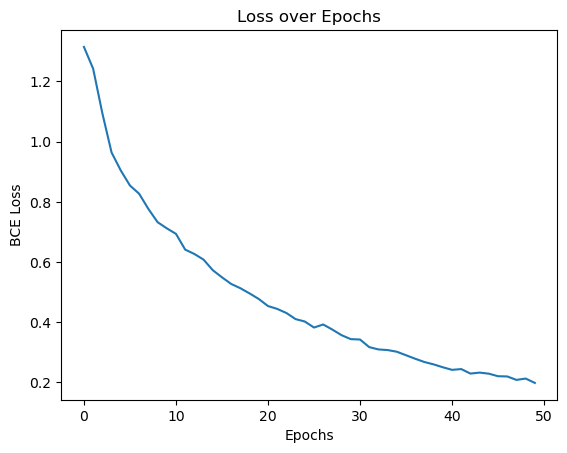

In [11]:
# plot loss
plt.plot(errors)
plt.xlabel("Epochs")
plt.ylabel("BCE Loss")
plt.title("Loss over Epochs")
#plt.savefig("train_loss.png")
plt.show()

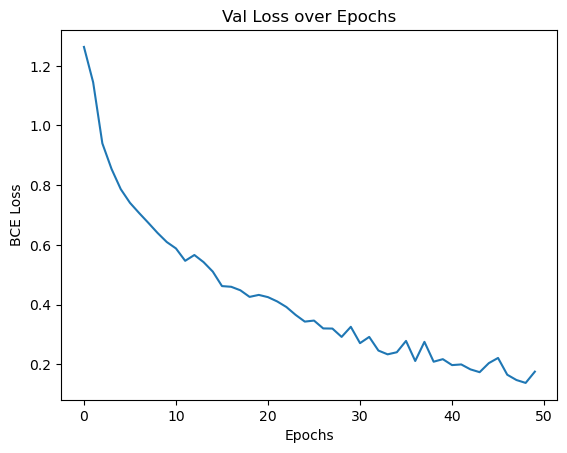

In [12]:
# plot loss
plt.plot(vals)
plt.xlabel("Epochs")
plt.ylabel("BCE Loss")
plt.title("Val Loss over Epochs")
#plt.savefig("val_loss.png")
plt.show()

In [19]:
epv_model.eval()
y_preds = epv_model(torch.FloatTensor(X_test_strat.values)).to(device).detach().numpy()

In [20]:
output = 1 / (1 + np.exp(-y_preds))

/var/folders/rr/7hqln5dd7_55vxvrgjhmz1gw0000gn/T/ipykernel_44039/4292051033.py:1: RuntimeWarning: overflow encountered in exp
  output = 1 / (1 + np.exp(-y_preds))


In [21]:
print(output)

[[1.2239077e-06]
 [1.9800957e-01]
 [3.5518653e-08]
 ...
 [8.1862372e-06]
 [3.3319029e-07]
 [8.5846901e-01]]


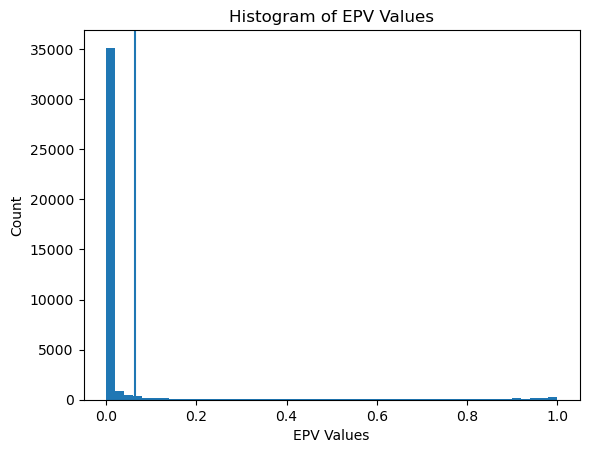

In [23]:
plt.hist(output, bins=50, range=(0,1))
plt.axvline(np.mean(output))
plt.xlabel("EPV Values")
plt.ylabel("Count")
plt.title("Histogram of EPV Values")
plt.show()

In [24]:
print(np.mean(output))

0.06485692


In [41]:
print(min(y_preds))
print(max(y_preds))
np.mean(y_preds)

[0.]
[1.]


np.float32(0.06304909)

In [25]:
torch.save(epv_model, "epv_model_logits.pth")

In [5]:
PITCH_WIDTH = 68
PITCH_LENGTH = 105

width_min = -PITCH_WIDTH/2
width_max = PITCH_WIDTH/2
length_min = -PITCH_LENGTH/2
length_max = PITCH_LENGTH/2

In [6]:
model = EPV()
model = torch.load("epv_model_logits.pth", weights_only=False)

C:\Users\miale.a\AppData\Local\Temp\ipykernel_21492\1568838664.py:2: RuntimeWarning: overflow encountered in exp
  output = 1 / (1 + np.exp(-new_preds))


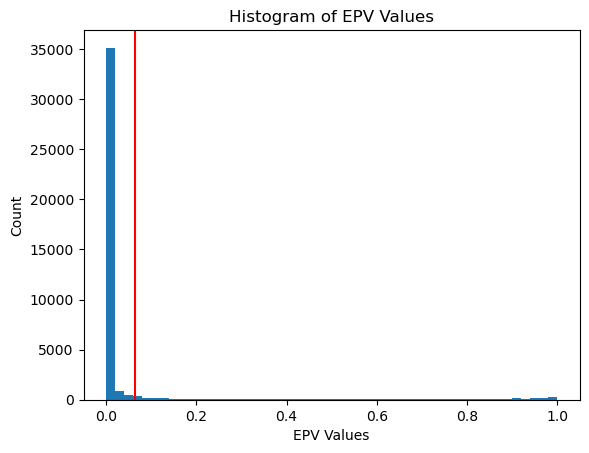

In [7]:
new_preds = model(torch.FloatTensor(X_test_strat.values)).detach().numpy()
output = 1 / (1 + np.exp(-new_preds))
plt.hist(output, bins=50, range=(0,1))
plt.axvline(np.mean(output), color="red")
plt.xlabel("EPV Values")
plt.ylabel("Count")
plt.title("Histogram of EPV Values")
plt.show()

In [11]:
np.mean(output)

np.float32(0.06485692)

In [12]:
print(roc_auc_score(y_test_strat, output))

0.9936043815877087


In [123]:
lower = tuple(np.argwhere(new_preds>0.99)[:, 0])
upper = tuple(np.argwhere(new_preds<=1.)[:, 0])
print(random.choice(list(set(lower) & set(upper))))

8418


In [110]:
print(lower)

(np.int64(130), np.int64(151), np.int64(153), np.int64(234), np.int64(314), np.int64(316), np.int64(377), np.int64(447), np.int64(460), np.int64(497), np.int64(559), np.int64(564), np.int64(575), np.int64(586), np.int64(622), np.int64(644), np.int64(678), np.int64(695), np.int64(710), np.int64(765), np.int64(781), np.int64(786), np.int64(791), np.int64(809), np.int64(827), np.int64(828), np.int64(898), np.int64(911), np.int64(951), np.int64(970), np.int64(974), np.int64(986), np.int64(995), np.int64(1006), np.int64(1010), np.int64(1021), np.int64(1053), np.int64(1054), np.int64(1059), np.int64(1060), np.int64(1077), np.int64(1107), np.int64(1149), np.int64(1156), np.int64(1205), np.int64(1230), np.int64(1298), np.int64(1300), np.int64(1306), np.int64(1318), np.int64(1337), np.int64(1342), np.int64(1366), np.int64(1405), np.int64(1425), np.int64(1434), np.int64(1442), np.int64(1456), np.int64(1457), np.int64(1506), np.int64(1552), np.int64(1566), np.int64(1582), np.int64(1603), np.int64

In [98]:
print(upper)

(np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int64(69), np.int64(70), np.int64(71), n

In [95]:
new_preds[8196]

array([0.9999573], dtype=float32)

In [103]:
print(X_test_strat.iloc[622])
y_test_strat.iloc[622]
epv_1 = X_test_strat.iloc[16389]

x1             0.02
x2             0.27
x3             0.12
x4             0.19
x5             0.12
               ... 
finish         1.00
quick_break    0.00
set_play       0.00
transition     0.00
direction      0.00
Name: 138600, Length: 167, dtype: float64


In [12]:
x1 = ["x1", "x2", "x3", "x4", "x5", "x6", "x7", "x8", "x9", "x10", "x11"]
x2 = ["x12", "x13", "x14", "x15", "x16", "x17", "x18", "x19", "x20", "x21", "x22"]
y1 = ["y1", "y2", "y3", "y4", "y5", "y6", "y7", "y8", "y9", "y10", "y11"]
y2 = ["y12", "y13", "y14", "y15", "y16", "y17", "y18", "y19", "y20", "y21", "y22"]

In [104]:
x1_vals = epv_1[x1]*length_max - epv_1[x1]*length_min + length_min
x2_vals = epv_1[x2]*length_max - epv_1[x2]*length_min + length_min

y1_vals = epv_1[y1]*width_max - epv_1[y1]*width_min + width_min
y2_vals = epv_1[y2]*width_max - epv_1[y2]*width_min + width_min

x_ball = epv_1["ball_x"]
y_ball = epv_1["ball_y"]

In [105]:
print(x_ball)

-20.33


In [106]:
epv_1["direction"]

np.float64(0.0)

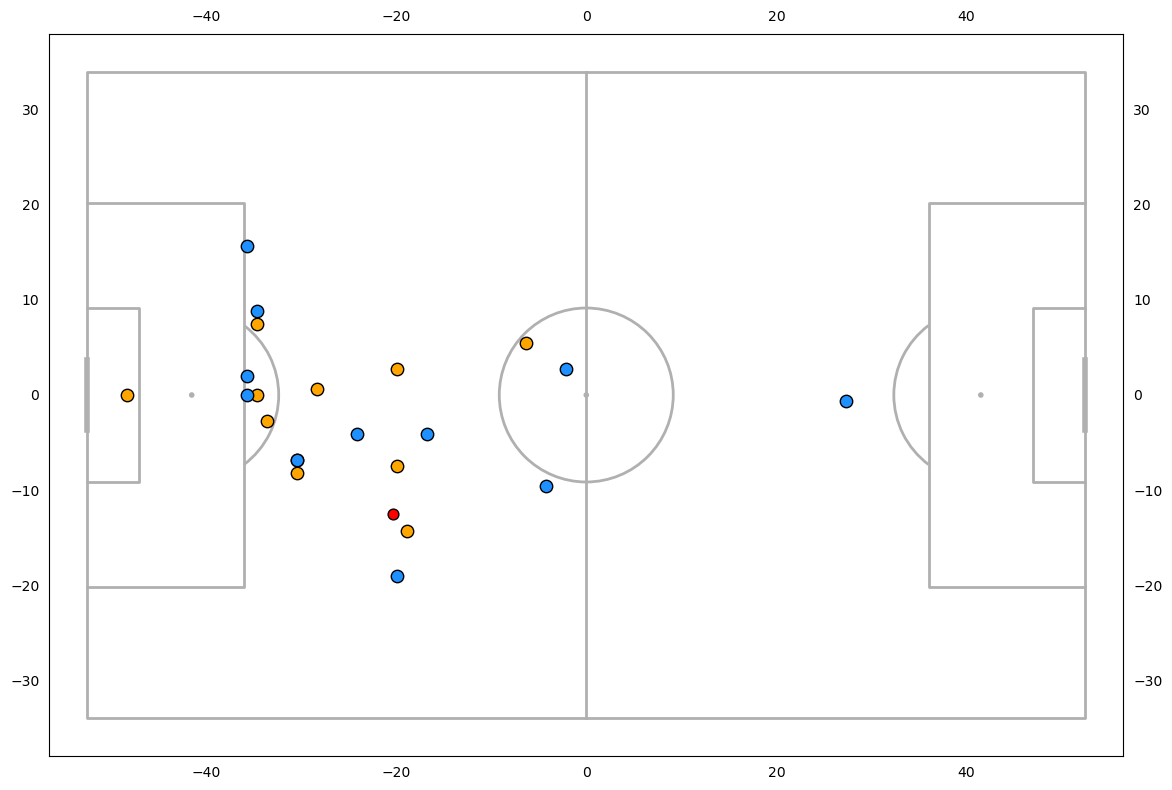

In [ ]:
# plot snapshot
p = Pitch(pitch_type="skillcorner", pitch_length=105, pitch_width=68, axis=True, label=True)
fig, ax = p.draw(figsize=(12,8))

# Plot players
sc1 = p.scatter(x1_vals, y1_vals, c='orange', s=80, ec='k', ax=ax)
sc2 = p.scatter(x2_vals, y2_vals, c='dodgerblue', s=80, ec='k', ax=ax)
ball = p.scatter(x_ball, y_ball, c='red', s=60, ec='k', ax=ax)

In [46]:
print(epv_1["ball_z"])

4.88


In [14]:
def plot_epv(min, max):
    """
    Print a pitch of an epv value in between the two values passed
    """

    # get indices of bounds
    lower = tuple(np.argwhere(new_preds>min)[:, 0])
    upper = tuple(np.argwhere(new_preds<=max)[:, 0])
    indices = list(set(lower) & set(upper))

    # pick an index
    index = random.choice(indices)
    
    # get epv
    epv = X_test_strat.iloc[index]
    actual_epv = new_preds[index]

    # get values
    x1_vals = epv[x1]*length_max - epv[x1]*length_min + length_min
    x2_vals = epv[x2]*length_max - epv[x2]*length_min + length_min

    y1_vals = epv[y1]*width_max - epv[y1]*width_min + width_min
    y2_vals = epv[y2]*width_max - epv[y2]*width_min + width_min

    x_ball = epv["ball_x"]
    y_ball = epv["ball_y"]

    # plot voronoi of snapshot
    p = Pitch(pitch_type="skillcorner", pitch_length=105, pitch_width=68, axis=True, label=True)
    fig, ax = p.draw(figsize=(12,8))

    # Plot players
    sc1 = p.scatter(x1_vals, y1_vals, c='orange', s=80, ec='k', ax=ax)
    sc2 = p.scatter(x2_vals, y2_vals, c='dodgerblue', s=80, ec='k', ax=ax)
    ball = p.scatter(x_ball, y_ball, c='red', s=60, ec='k', ax=ax)
    ax.set_title(f"EPV of {actual_epv}")
    

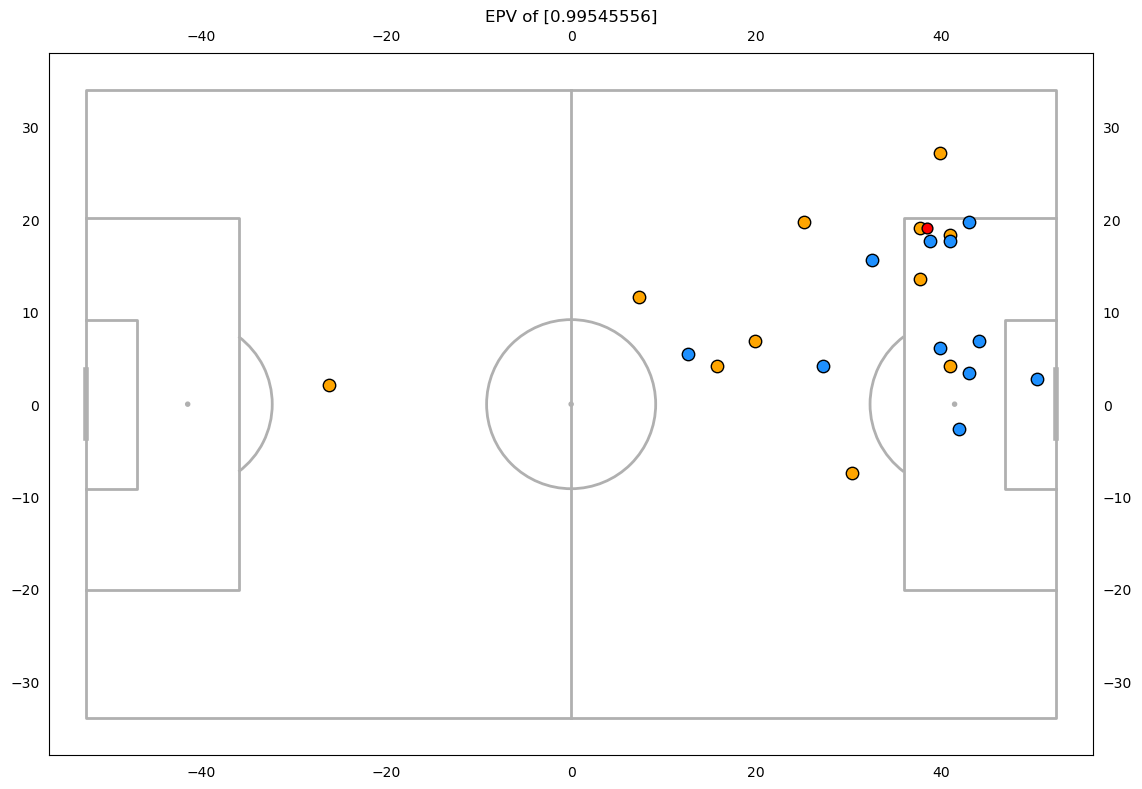

In [50]:
plot_epv(0.99, 1)

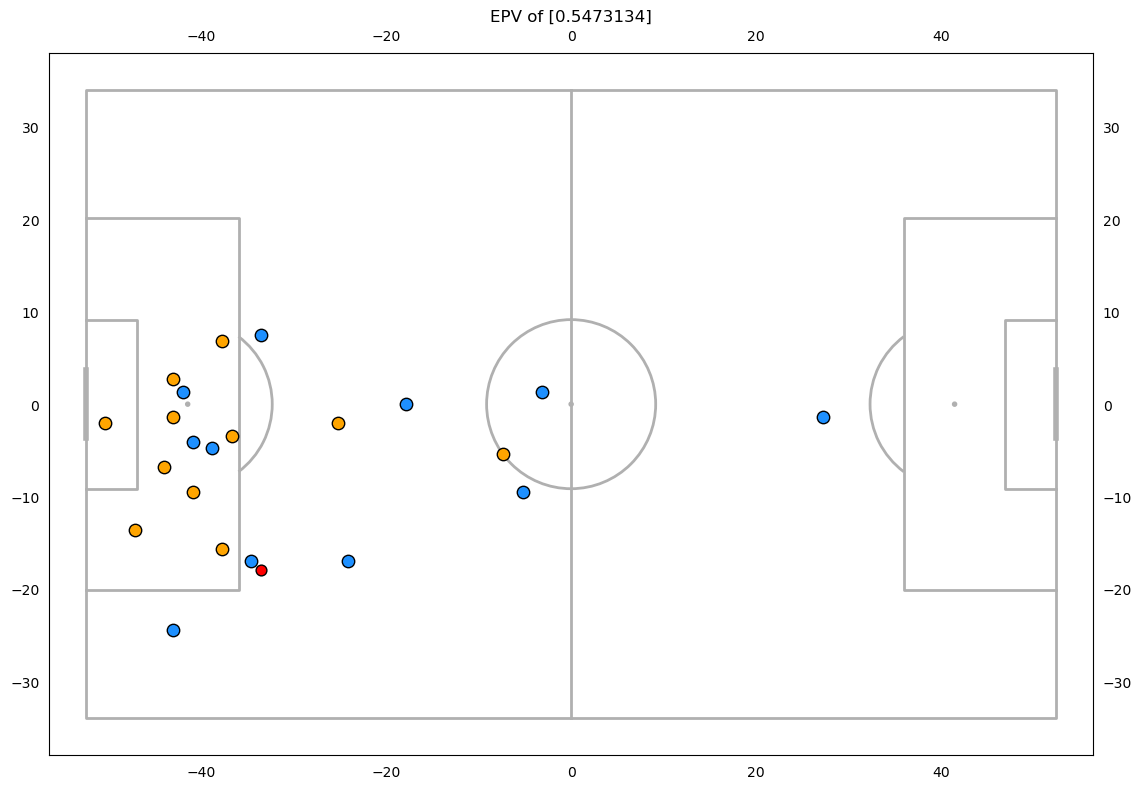

In [55]:
plot_epv(0.45, 0.55)

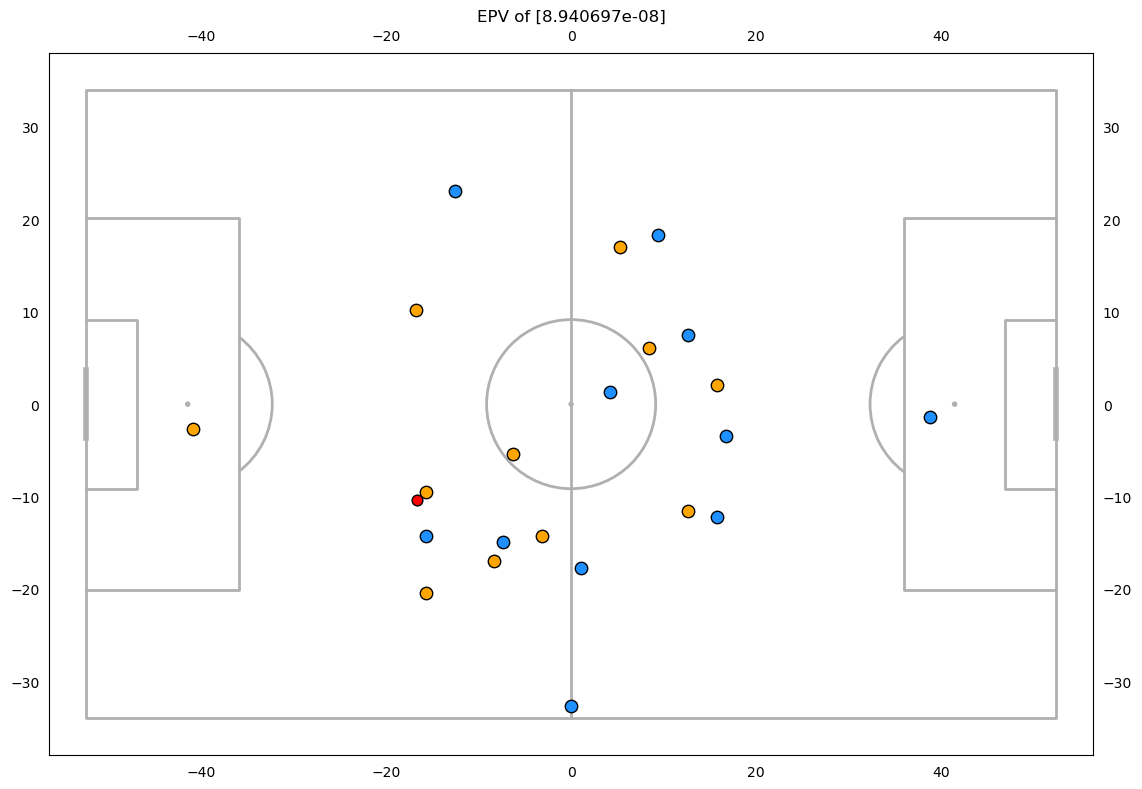

In [56]:
plot_epv(0, 0.05)